# SMA Crossover Strategy Sim
_A simple trend-following backtest utilizing moving average crossovers_


### Import Libraries & Pull Data

In [1066]:
# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set our time window (factor in the 50 day waiting period for SMA to kick in)
start_date = '2019-10-12'
end_date = '2024-12-30'
 
# Type in any ticker to analyze its behavior against tTS stratefy
ticker = 'QQQ'
data = yf.download(ticker, start_date, end_date)

# For our purposes, we only want the closing prices
data = data[['Close']].dropna()

# We want to set our windows and take the mean of the closing prices between-- this will be the backbone of our analysis
short_window = 20
long_window = 50
data['SMA20'] = data['Close'].rolling(window=short_window).mean()
data['SMA50'] = data['Close'].rolling(window=long_window).mean()

[*********************100%***********************]  1 of 1 completed


### Generate Buy/Sell Signals

In [1068]:
# This is where we generate our signals, iterate thru dataframe looking for zero crossovers
# This is actually a physics concept and can be helpful for finding change in acceleration
# Or in simpler terms-- momentum. This is literally the inertia of the system.
data['Signal'] = 0
data.loc[data.index[short_window:], 'Signal'] = np.where(
    data['SMA20'][short_window:] > data['SMA50'][short_window:], 1, 0
)

# This is just the 'change in' which tells us whether to buy or sell
data['Position'] = data['Signal'].diff()

# Knock off everything after the long window for analysis purposes
data_sub = data.iloc[long_window:].copy()

### Plot Trends

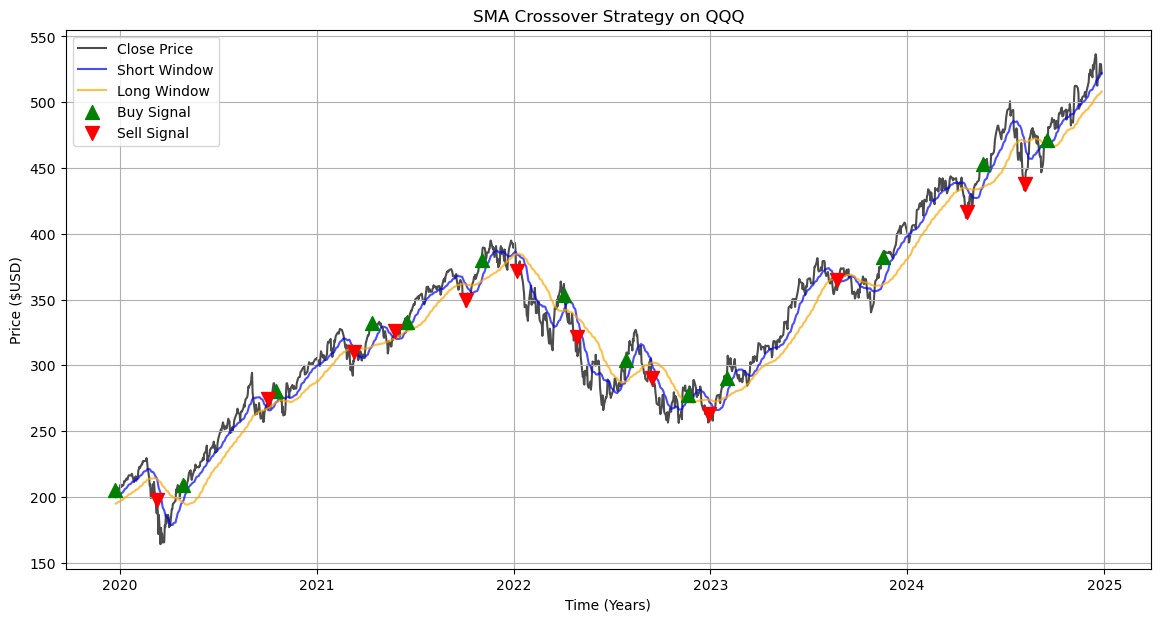

In [1070]:
# Plot the lines
plt.figure(figsize=(14,7))
plt.plot(data_sub['Close'], label='Close Price', alpha=0.7, color='black', zorder=0)
plt.plot(data_sub['SMA20'], label='Short Window', alpha=0.7, color='blue', zorder=5)
plt.plot(data_sub['SMA50'], label='Long Window', alpha=0.7, color='orange', zorder=10)
plt.grid()
plt.xlabel('Time (Years)')
plt.ylabel('Price ($USD)')

# Mark buy & sell signals
plt.scatter(data.index[data['Position'] ==  1], data['Close'][data['Position'] ==  1], 
            label='Buy Signal',  marker='^', color='green', s=100, zorder=15)
plt.scatter(data.index[data['Position'] == -1], data['Close'][data['Position'] == -1], 
            label='Sell Signal', marker='v', color='red',   s=100, zorder=20)

plt.title(f"SMA Crossover Strategy on {ticker}")
plt.legend()

### Simulate Portfolio

In [1072]:
# Initialize variables + lists for datatype purposes
initial_capital = 10000
cash            = initial_capital
shares          = 0

cash_list   = []
shares_list = []
stock_val  = []
total_val  = []

# Iterate thru each day and checking whether to buy or sell
for i in range(len(data)):
    sig   = data['Position'].iloc[i]   # Always a scalar
    price = data['Close'].iloc[i]      # Always a scalar

    if sig == 1:
        to_buy = (cash // price).item()
        cash  -= to_buy * price
        shares += to_buy

    elif sig == -1:
        cash   += shares * price
        shares  = 0

    # Record daily snapshot
    cash_list.append(cash)
    shares_list.append(shares)
    stock_val.append(shares * price)
    total_val.append(cash + shares * price)

# Bulk‐assign back into DataFrame
data['Cash']        = cash_list
data['Shares']      = shares_list
data['Stock Value'] = stock_val
data['Total Value'] = total_val
data['Returns']     = data['Total Value'].pct_change()

### Performance Metrics

C:\Users\tobys\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
C:\Users\tobys\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


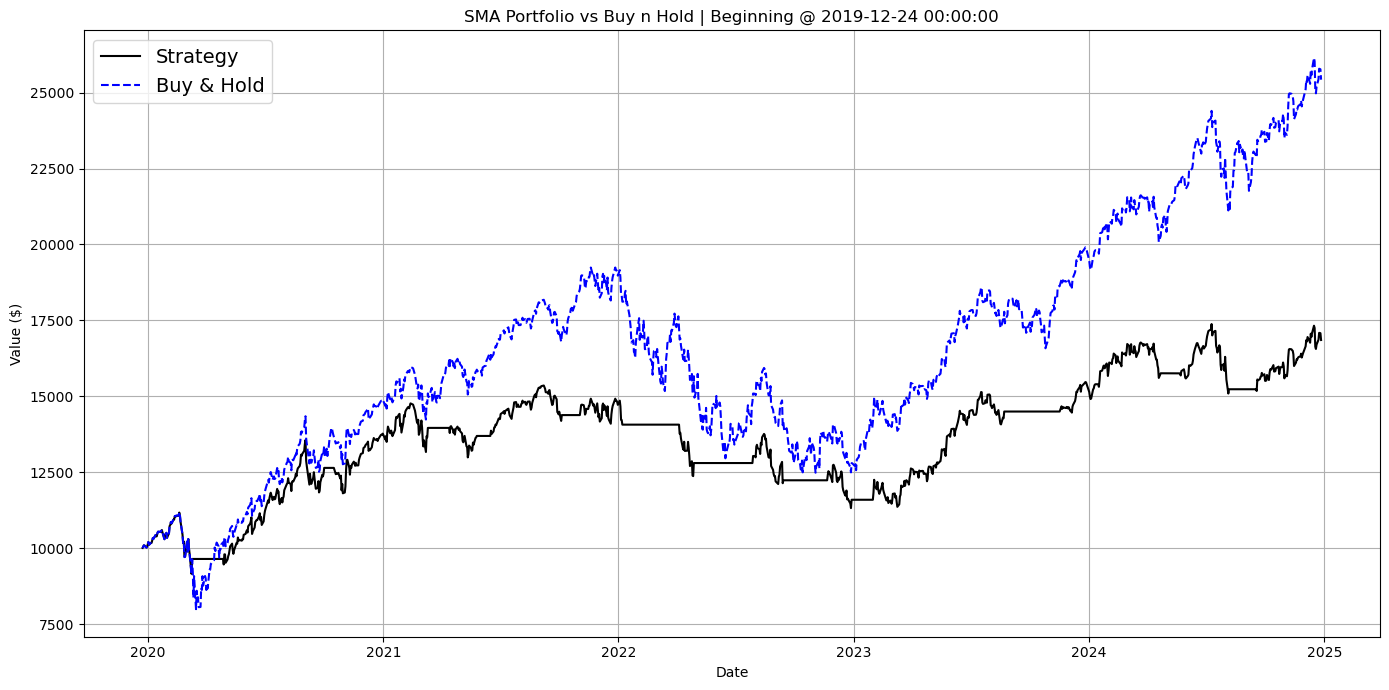

In [1074]:
# Knock off everything after the long window for analysis purposes
# We do this AGAIN for simplicity purposes
data_sub = data.iloc[long_window:].copy()
data_sub['BuyHold'] = initial_capital * (data_sub['Close'] / data_sub['Close'].iloc[0])

plt.figure(figsize=(14,7))
plt.plot(data_sub['Total Value'], label='Strategy', color='black', linewidth=1.5)
plt.plot(data_sub['BuyHold'],     label='Buy & Hold', color='blue',  linewidth=1.5, linestyle = '--')
plt.title(f'SMA Portfolio vs Buy n Hold | Beginning @ {data_sub.index[0]}')
plt.xlabel('Date') 
plt.ylabel('Value ($)')
plt.legend(prop={'size': 14})
plt.grid()
plt.tight_layout()
plt.grid(True)
plt.show()